In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range

import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 12,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
data_type = 'data_vMB_ring_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
print("Model loaded")

Model loaded


y_mean: 0.7356226400072773 | y_std: 0.6774234928800895


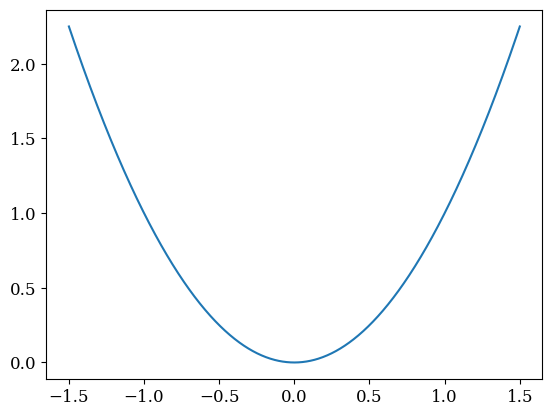

In [25]:
vmin = -1.5
vmax = 1.5

X = np.linspace(vmin, vmax, 1024)
def target_function(x):
    return x**2#np.sin(3*x)#x**2#np.cos(3*x)
y = target_function(X)# + np.exp(0.5*X**2) + np.random.normal(loc=0.0, scale=0.05)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

train_target_mu, train_target_sigma = y_train.mean(), y_train.std()
print(f'y_mean: {train_target_mu} | y_std: {train_target_sigma}')

train_x = torch.from_numpy(X_train).unsqueeze(-1).float()
test_x = torch.from_numpy(X_test).unsqueeze(-1).float()
train_y = torch.from_numpy(y_train).unsqueeze(-1).float()
test_y = torch.from_numpy(y_test).unsqueeze(-1).float()  

train_set = TensorDataset(train_x, train_y)
test_set = TensorDataset(test_x, test_y)

batch_size = 64
train_loader = DataLoader(train_set, batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size, shuffle=False)

plt.plot(X, y)

In [27]:
for p in model.parameters():
    if p.requires_grad == True:
        p.requires_grad_(False)

model.eval()
model = model.to(device)

input_index = 3
num_voltages = model.layer_dims[0]
cmin = -1.5
cmax = 1.5

control_indices = [c_idx for c_idx in range(num_voltages) if c_idx != input_index]

control_volts = torch.nn.Parameter(torch.randn(num_voltages - 1, device=device))
gain = torch.nn.Parameter(torch.tensor(1.0, device=device))
offset = torch.nn.Parameter(torch.tensor(0.0, device=device))

#input_range = torch.linspace(v_min, v_max, 100)

num_epochs = 1_000
optimizer = torch.optim.Adam(params=[control_volts, gain, offset], lr=4e-3)
loss_fn = torch.nn.MSELoss()

for e in range(1, num_epochs):
    optimizer.zero_grad() 
    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)
        input_tensor = torch.zeros(x.size(0), num_voltages, device=device)
        input_tensor[:, control_indices] = control_volts.unsqueeze(0).expand(x.size(0), -1)
        input_tensor[:, input_index] = x.view(-1)

        pred = gain * model(input_tensor) + offset
        
        loss = loss_fn(pred, y)
        loss.backward()

        optimizer.step()
        with torch.no_grad():
            control_volts.clamp_(cmin, cmax)
    if e % 100 == 0:
        print(f"Epoch training loss {e}/{num_epochs}:", loss.item() / len(train_loader.dataset))

print("Control voltages:", control_volts)
print("Gain:", gain)
print("Offset:", offset)

Epoch training loss 100/1000: 0.002985160429399092
Epoch training loss 200/1000: 0.001556835477314298
Epoch training loss 300/1000: 0.0010064212976066767
Epoch training loss 400/1000: 0.0003211710042569227
Epoch training loss 500/1000: 0.0001736616440599509
Epoch training loss 600/1000: 0.0003243402756468571
Epoch training loss 700/1000: 0.00025786579528571047
Epoch training loss 800/1000: 7.449344746650212e-05
Epoch training loss 900/1000: 0.000141739999927735
Control voltages: Parameter containing:
tensor([ 0.0374,  0.1672, -0.3732, -0.5112,  0.0915,  0.1687], device='cuda:0',
       requires_grad=True)
Gain: Parameter containing:
tensor(0.1525, device='cuda:0', requires_grad=True)
Offset: Parameter containing:
tensor(0.8094, device='cuda:0', requires_grad=True)


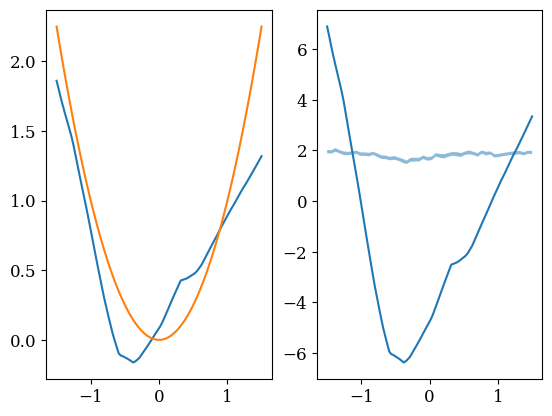

In [28]:
num_points = 100
input_range = torch.linspace(vmin, vmax, num_points)
gain = gain.detach().cpu()
offset = offset.detach().cpu()

voltage_input = torch.zeros(num_points, num_voltages)
voltage_input[:, control_indices] = control_volts.detach().cpu().unsqueeze(0).expand(num_points, -1)
voltage_input[:, input_index] = input_range

with torch.no_grad():
    voltage_input = voltage_input.to(device)
    y_out = model(voltage_input).detach().cpu()
    y_out = gain * y_out + offset

fig, ax = plt.subplots(ncols=2)

ax[0].plot(input_range, y_out)
ax[0].plot(input_range, target_function(input_range))

ax[1].plot(input_range, (y_out - offset) / gain)

data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_GD/gd_data_type=data_vMB_ring_1e7_func_type=Parabola_input_idx=3.npz')
I_out = data['current'] * 1e21 * gain.numpy() + offset.numpy()
I_err = data['sem'] * 1.96 * 1e21 * np.abs(gain.numpy())

ax[1].fill_between (np.linspace(vmin, vmax, I_out.shape[0]), I_out - I_err, I_out + I_err, alpha=.5)